# 0. 환경설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요

## 1. 기본정보

In [3]:
# 1-1 CSV 파일 불러오기

df = pd.read_csv("../../CSV_files/assessments.csv")
df.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [4]:
# 1-2 정보

df.info()

# ? 결측치 11건은 왜 있는가?
# ? id의 경우 중복값이 있는가?

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB


In [5]:
# 1-3 기술통계
# id는 식별자라 여기선 제외하고 봐야함

df.describe()

# date는 학기 시작일
# weight는 평가비중이라 과목별, 과제별로 확인해야함

,id_assessment,date,weight
count,206.000000,195.000000,206.000000
mean,26473.975728,145.005128,20.873786
std,10098.625521,76.001119,30.384224
min,1752.000000,12.000000,0.000000
25%,15023.250000,71.000000,0.000000
50%,25364.500000,152.000000,12.500000
75%,34891.750000,222.000000,24.250000
max,40088.000000,261.000000,100.000000


In [6]:
# 1-4 결측치 위치 조회
# Q4 질문 도출 : Exam 날짜 결측 -> 마지막 평가와의 간격은 과목마다 다를까?

df[df['date'].isna()][['code_module', 'code_presentation', 'assessment_type', 'weight']]

# ! 결측치 11건은 왜 있는가?
# 공식문서상 Exam의 결측의 경우, 마지막 주로 간주해야한다고 명시됨

,code_module,code_presentation,assessment_type,weight
5,AAA,2013J,Exam,100.0
11,AAA,2014J,Exam,100.0
23,BBB,2013B,Exam,100.0
35,BBB,2013J,Exam,100.0
47,BBB,2014B,Exam,100.0
53,BBB,2014J,Exam,100.0
62,CCC,2014B,Exam,100.0
63,CCC,2014B,Exam,100.0
72,CCC,2014J,Exam,100.0
73,CCC,2014J,Exam,100.0


## 2. 속성별 정보

In [7]:
# 1-1 속성 종류

df.columns

Index(['code_module', 'code_presentation', 'id_assessment', 'assessment_type',
       'date', 'weight'],
      dtype='str')

In [8]:
# 1-3 속성 데이터 타입

df.dtypes

code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

In [9]:
# 1-4 고유값 개수

df.nunique()

# code_module            7    → 값이 적음 → 범주형
# code_presentation      4    → 값이 적음 → 범주형
# id_assessment        206    → 전체 행수와 동일 → 식별자(ID), 분석 대상 아님
# assessment_type        3    → 값이 적음 → 범주형
# date                  74    → 값이 많고 연속적 → 수치형(연속)
# weight                24    → 적당히 적음 → 수치형이지만 범주처럼 볼 수도 있음

code_module            7
code_presentation      4
id_assessment        206
assessment_type        3
date                  74
weight                24
dtype: int64

### 0. 범주형과 수치형 속성의 조회 방법

### 1. dtype 기준 (기계적 구분)
pandas가 저장하고 있는 실제 데이터 타입으로 나누는 방법.

- `df.select_dtypes(include='number')` → 수치형 (int64, float64)
- `df.select_dtypes(exclude='number')` → 범주형 후보 (object, str)
- **한계**: 겉보기엔 숫자(int64)라도 의미상 범주형인 값(ID, 코드값)을 걸러내지 못함

### 2. 고유값 개수 기준 (의미적 구분)
`nunique()`로 컬럼별 고유값 개수를 세고, 전체 행 수(`len(df)`) 대비 비율로 판단.

- 고유값 개수가 전체 행 수 대비 적음 → **범주형**
- 고유값 개수가 전체 행 수와 비슷/동일 → **식별자(ID)** 또는 **연속형 수치**
- 정해진 절대 기준(threshold)은 없고, 상대적 판단 + 도메인 지식이 필요함

### 3. 두 기준을 같이 봐야 하는 이유
| 기준만 사용 시 | 문제점 |
|---|---|
| dtype만 사용 | `id_assessment`(int64)도 수치형으로 분류되지만 실제로는 식별자 |
| nunique만 사용 | 몇 개부터 범주형인지 절대 기준이 없어 애매함 |

→ 실무에서는 **dtype + nunique + 도메인 지식**을 종합해서 최종 판단

### 4. 이번 데이터셋(assessments.csv) 적용 예시
| 컬럼 | dtype | 고유값 개수 | 실제 구분 |
|---|---|---|---|
| code_module | str | 7 | 범주형 |
| code_presentation | str | 9 | 범주형 |
| id_assessment | int64 | 206 (전체 행 수와 동일) | 식별자 (분석 대상 제외) |
| assessment_type | str | 3 | 범주형 |
| date | float64 | 147 | 수치형 (연속) |
| weight | float64 | 14 | 수치형 |

### 1. 범주형 속성 조회

In [10]:
# 1-1 범주형 속성의 고유값 목록

for col in ['code_module', 'code_presentation', 'assessment_type']:
    print(f"[{col}] {df[col].unique()}")

[code_module] <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
Length: 7, dtype: str
[code_presentation] <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str
[assessment_type] <StringArray>
['TMA', 'Exam', 'CMA']
Length: 3, dtype: str


In [11]:
# 1-2 범주형 속성별 값 분포(개수와 비율)  
# # Q1 질문 도출 : 평가가 촘촘한 과목일수록 부담이 커서 이탈과 관련될까?
# Q5 질문 도출 : code_presentation별 개수 차이(2013B만 적음) -> 학기별 스케줄 패턴과 연관될까?

for col in ['code_module', 'code_presentation', 'assessment_type']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3))
    print()

--- code_module ---
code_module
FFF    52
BBB    42
DDD    35
GGG    30
CCC    20
EEE    15
AAA    12
Name: count, dtype: int64
code_module
FFF    0.252
BBB    0.204
DDD    0.170
GGG    0.146
CCC    0.097
EEE    0.073
AAA    0.058
Name: proportion, dtype: float64

--- code_presentation ---
code_presentation
2014J    57
2014B    57
2013J    53
2013B    39
Name: count, dtype: int64
code_presentation
2014J    0.277
2014B    0.277
2013J    0.257
2013B    0.189
Name: proportion, dtype: float64

--- assessment_type ---
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64
assessment_type
TMA     0.515
CMA     0.369
Exam    0.117
Name: proportion, dtype: float64



In [12]:
# 1-3 범주형 / 수치형 속성 자동 분류
# 저장된 dtype을 기준으로 분류

num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print('수치형:', num_cols)
print('범주형:', cat_cols)

수치형: ['id_assessment', 'date', 'weight']
범주형: ['code_module', 'code_presentation', 'assessment_type']


### 3. 수치형 속성 조회

In [13]:
# 1-1 기술통계

num_cols = ['date', 'weight']  # id_assessment는 식별자라 제외  

# Q2 질문 파생

df[num_cols].describe()

,date,weight
count,195.000000,206.000000
mean,145.005128,20.873786
std,76.001119,30.384224
min,12.000000,0.000000
25%,71.000000,0.000000
50%,152.000000,12.500000
75%,222.000000,24.250000
max,261.000000,100.000000


In [14]:
# 1-2 왜도, 첨도 확인 -> 분포가 한쪽으로 치우쳤는지
# skew() : 0에 가까우면 좌우 대칭, 양수면 오른쪽 꼬리(큰 값 쪽)가 길게 늘어짐, 음수면 왼쪽 꼬리
# kurt() : 0에 가까우면 정규분포와 비슷한 뾰족함, 양수면 뾰족+꼬리가 두꺼움(극단값 많음)
# Q3 질문 도출 : weight 왜도(치우침)가 큰 이유 -> 과목별 비중 편중과 관련될까?

for col in num_cols:
    print(f"[{col}] skew={df[col].skew():.3f}, kurt={df[col].kurt():.3f}")

[date] skew=-0.256, kurt=-1.369
[weight] skew=1.962, kurt=2.587


In [15]:
# 1-3 사분위수

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(f"[{col}] Q1={q1}, Q3={q3}, IQR={iqr}")

[date] Q1=71.0, Q3=222.0, IQR=151.0
[weight] Q1=0.0, Q3=24.25, IQR=24.25


In [16]:
# 1-4 이상치 개수 - IQR 기준

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"[{col}] 이상치 개수: {len(outliers)} (기준: {lower:.1f} ~ {upper:.1f})")

[date] 이상치 개수: 0 (기준: -155.5 ~ 448.5)
[weight] 이상치 개수: 24 (기준: -36.4 ~ 60.6)


### 4. 식별자의 무결성 체크

In [17]:
print(df['id_assessment'].is_unique)          # True면 중복 없는 진짜 식별자
print(df['id_assessment'].duplicated().sum()) # 중복 개수 (0이어야 정상)

# ! id의 경우 중복값이 있는가?
# 중복값 없음, 식별자로써 문제없음

True
0


### assessments.csv 속성 정리

| 컬럼명 | 타입 | 설명 | 값 예시 / 범위 | 결측치 |
|---|---|---|---|---|
| code_module | object | 모듈(과목) 식별 코드 | AAA, BBB, CCC, DDD, EEE, FFF, GGG (7종) | 0 |
| code_presentation | object | 개강 학기 코드. 연도 + B(2월 개강)/J(10월 개강) | 2013B, 2013J, 2014B, 2014J (4종) | 0 |
| id_assessment | int64 | 평가(과제/시험) 고유 ID | 206개 고유값 | 0 |
| assessment_type | object | 평가 유형 | TMA(과제), CMA(컴퓨터 채점 과제), Exam(기말시험) | 0 |
| date | float64 | 학기 시작일(0) 기준 제출 마감일(일수) | 19 ~ 261일 범위 | 11건 (Exam 날짜 미기재 → 마지막 주로 간주) |
| weight | float64 | 평가 비중(%). Exam은 보통 100%, 나머지 합이 100% | 0, 1, 2, 5, 10, 18, 20, 30, 35, 100 등 | 0 |

**행/열 구조**: 206 rows × 6 columns

**참고**
- weight가 0인 항목은 실제 성적 반영 없는 형성평가성 과제일 수 있음
- date 결측 11건은 공식 문서 기준 "마지막 주"로 처리하는 것이 관례

# 2. 그래프 및 구조

## 1. 범주형/수치형 속성 구분

### 1. 범주형 / 수치형 구분 방법

**① dtype 기준 (기계적 구분)**
pandas가 저장하고 있는 실제 데이터 타입으로 나누는 방법.
- `df.select_dtypes(include='number')` → 수치형 (int64, float64)
- `df.select_dtypes(exclude='number')` → 범주형 후보 (str, object)
- 한계: 겉보기엔 숫자(int64)라도 의미상 범주형인 값(ID, 코드값)을 걸러내지 못함

**② 고유값 개수 기준 (의미적 구분)**
`nunique()`로 컬럼별 고유값 개수를 세고, 전체 행 수(`len(df)`) 대비 비율로 판단.
- 고유값 개수가 전체 행 수 대비 적음 → **범주형**
- 고유값 개수가 전체 행 수와 비슷/동일 → **식별자(ID)** 또는 **연속형 수치**
- 정해진 절대 기준(threshold)은 없고, 상대적 판단 + 도메인 지식 필요

→ 실무에서는 **dtype + nunique + 도메인 지식**을 종합해서 최종 판단

### 2. 그래프 그리는 요령: "구분 먼저, 그래프는 나중"

그래프를 먼저 그리고 맞춰가는 게 아니라, **1번에서 범주형/수치형을 먼저 나눠놓고**, 그 그룹에 맞는 그래프 함수를 적용하는 순서가 맞음.

| 구분 | 그래프 | x축의 의미 | 막대 1개의 의미 | bins 필요 여부 |
|---|---|---|---|---|
| 범주형 | `countplot` | 이미 존재하는 고유값 그 자체 | 카테고리 1개 | 불필요 (이미 이산적으로 구분됨) |
| 수치형 | `histplot` | 값을 구간으로 쪼갠 것 | 값 범위(구간) 1개 | 필요 (연속형이라 인위적으로 나눠야 분포가 보임) |

즉 `bins`가 있고 없고는 결과적인 코드 차이일 뿐이고, 근본 이유는 **범주형은 이미 나뉘어 있어 그대로 세면 되고, 수치형은 값이 다 달라서 구간으로 묶어야 분포를 읽을 수 있다**는 데 있음.

### 3. 이번 데이터셋(assessments.csv) 적용 예시

| 컬럼 | dtype | 고유값 개수 | 구분 | 사용할 그래프 |
|---|---|---|---|---|
| code_module | str | 7 | 범주형 | countplot |
| code_presentation | str | 9 | 범주형 | countplot |
| id_assessment | int64 | 206 (전체 행 수와 동일) | 식별자 (분석 제외) | - |
| assessment_type | str | 3 | 범주형 | countplot |
| date | float64 | 147 | 수치형 (연속) | histplot |
| weight | float64 | 14 | 수치형 | histplot |

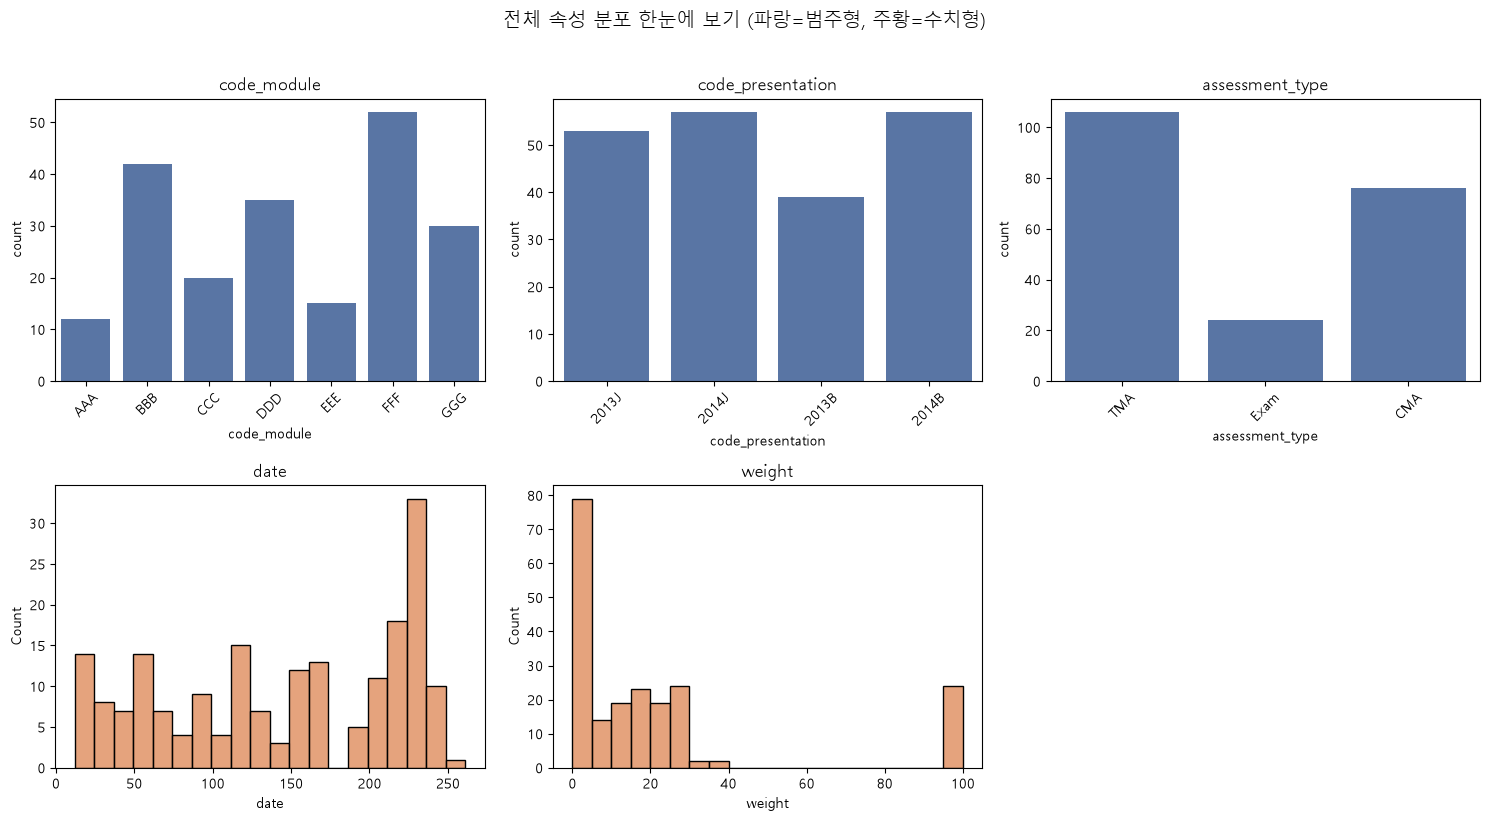

In [18]:
cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']
cols = cat_cols + num_cols

ncols = 3
nrows = -(-len(cols) // ncols)  # 올림 나눗셈

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    if col in cat_cols:
        sns.countplot(data=df, x=col, color='#4C72B0', ax=ax)
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.histplot(data=df, x=col, bins=20, color='#DD8452', ax=ax)
    ax.set_title(col)

# 남는 빈 액자 제거
for ax in axes[len(cols):]:
    fig.delaxes(ax)

fig.suptitle('전체 속성 분포 한눈에 보기 (파랑=범주형, 주황=수치형)', fontsize=14, y=1.02)
plt.tight_layout()

# ? 평가 비중이 0~5% 가 많은 이유? : 아마 TMA, CMA 의 영향일 가능성있음

plt.show()

## 2. 범주형 그래프

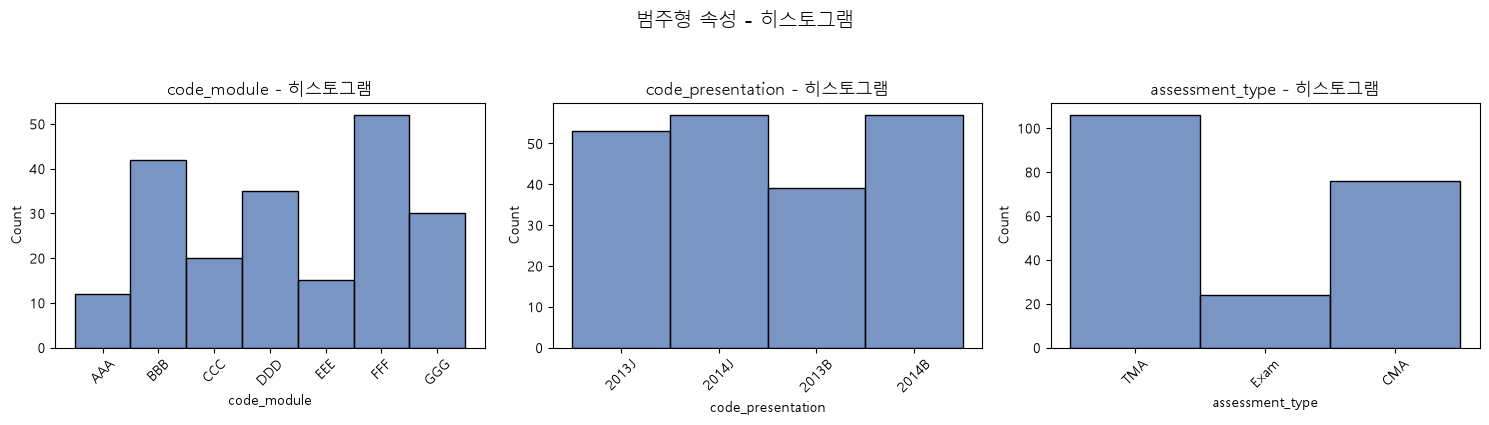

In [19]:
# 1-1 히스토그램

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    sns.histplot(data=df, x=col, discrete=True, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 히스토그램')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('범주형 속성 - 히스토그램', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

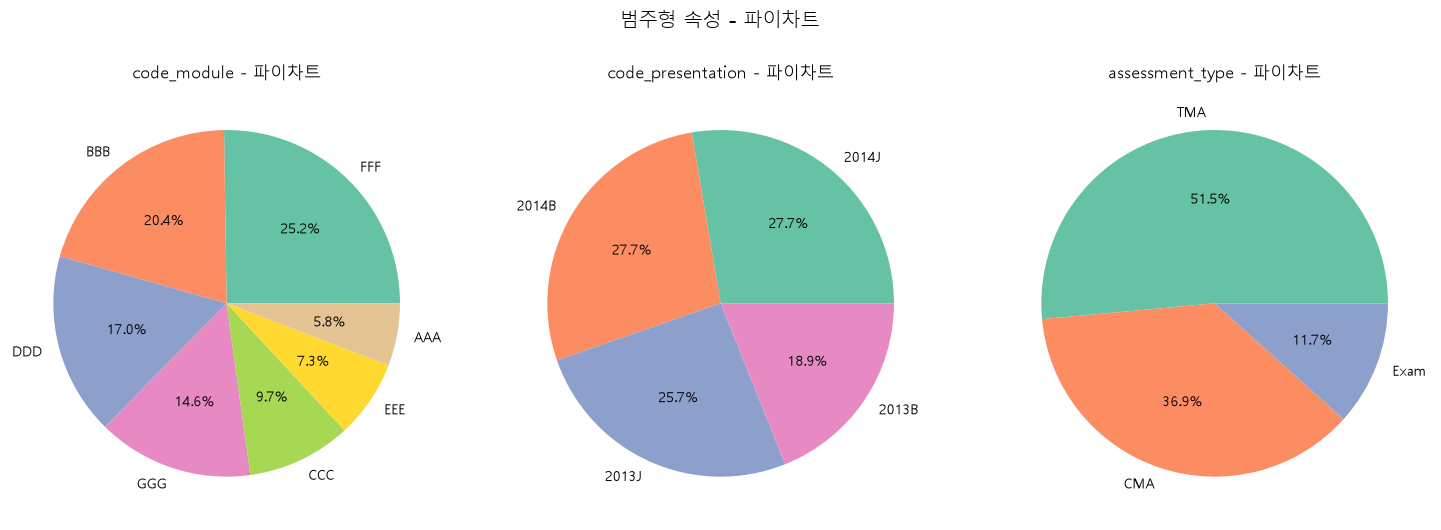

In [20]:
# 1-2 파이차트

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{col} - 파이차트')

fig.suptitle('범주형 속성 - 파이차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

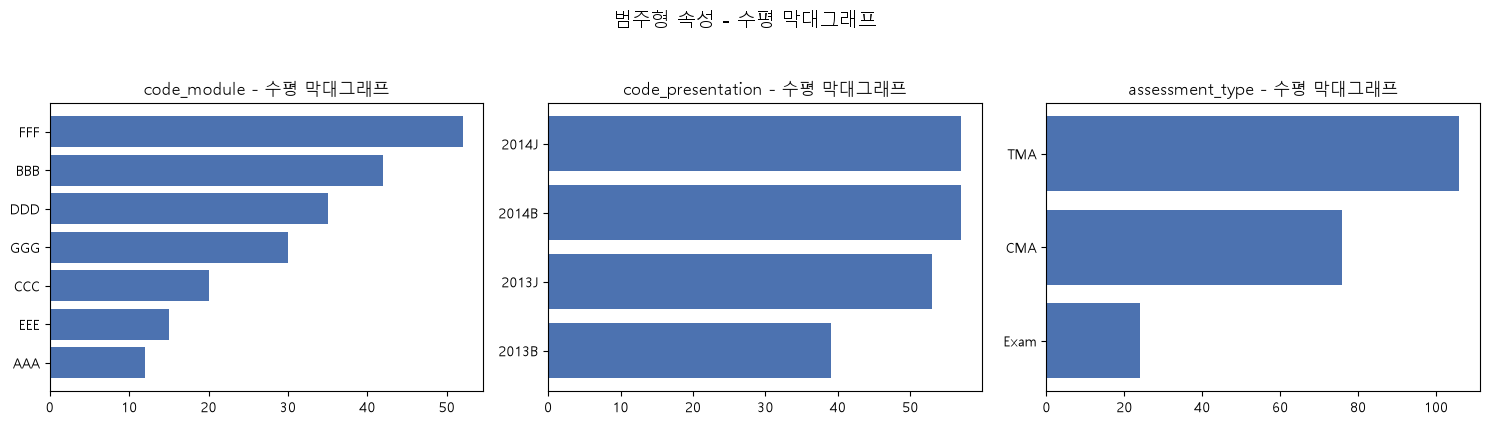

In [21]:
# 1-3 수평 막대 그래프

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color='#4C72B0')
    ax.invert_yaxis()  # 개수 많은 순서대로 위에서부터 표시
    ax.set_title(f'{col} - 수평 막대그래프')

fig.suptitle('범주형 속성 - 수평 막대그래프', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


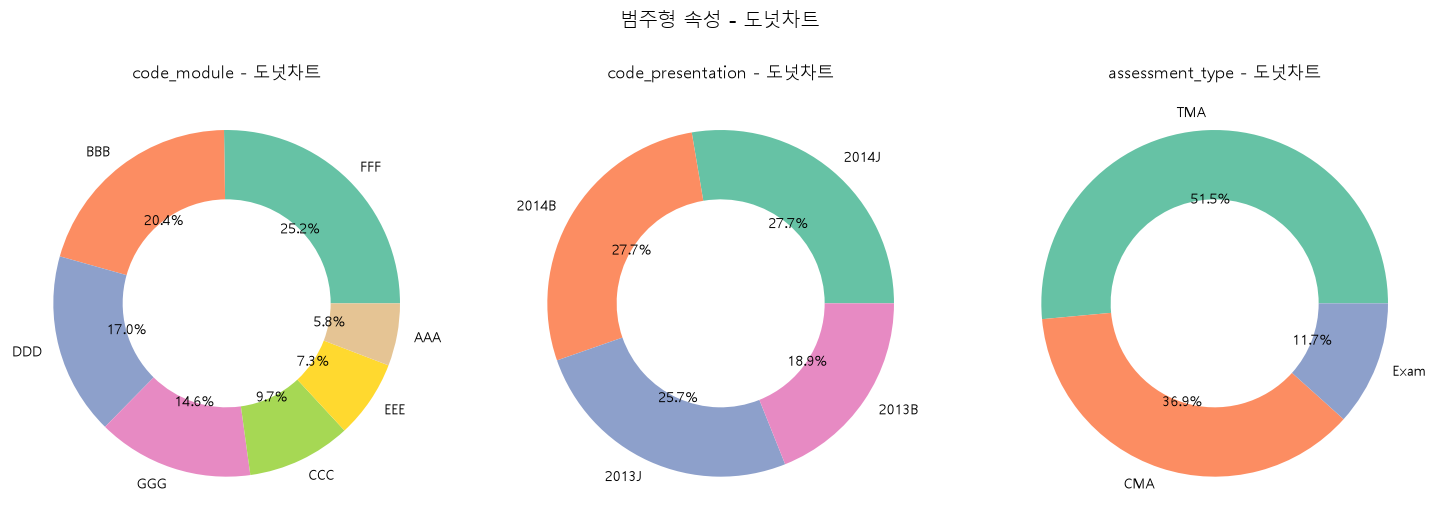

In [22]:
# 1-4 도넛차트

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)),
           wedgeprops={'width': 0.4})  # width로 도넛 두께 조절
    ax.set_title(f'{col} - 도넛차트')

fig.suptitle('범주형 속성 - 도넛차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

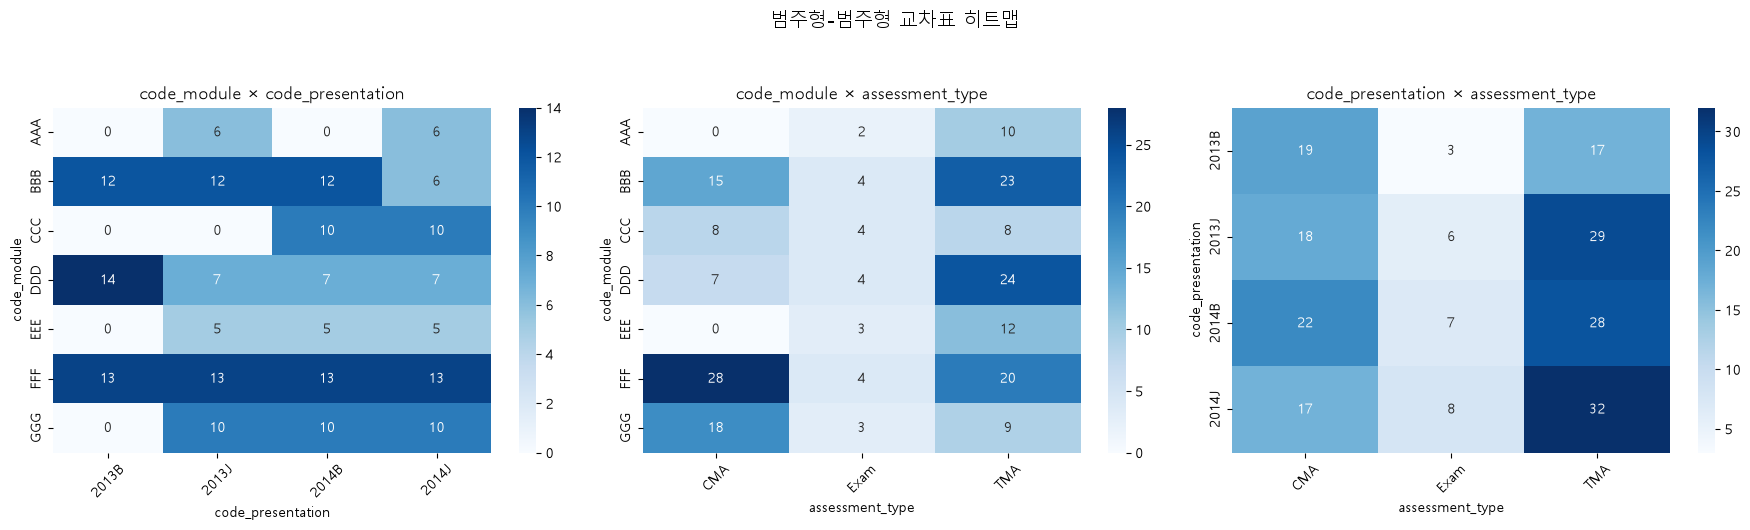

In [23]:
# 1-5 히트맵(범주형 끼리 관계)
# (code_module, code_presentation), (code_module, assessment_type), (code_presentation, assessment_type)
# Q5 질문 도출 : 모듈-학기 조합 중 비어있는 셀 확인 -> 미개설 모듈 여부

pairs = list(combinations(cat_cols, 2))  
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))

for ax, (col1, col2) in zip(axes, pairs):
    cross = pd.crosstab(df[col1], df[col2])
    sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{col1} × {col2}')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('범주형-범주형 교차표 히트맵', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

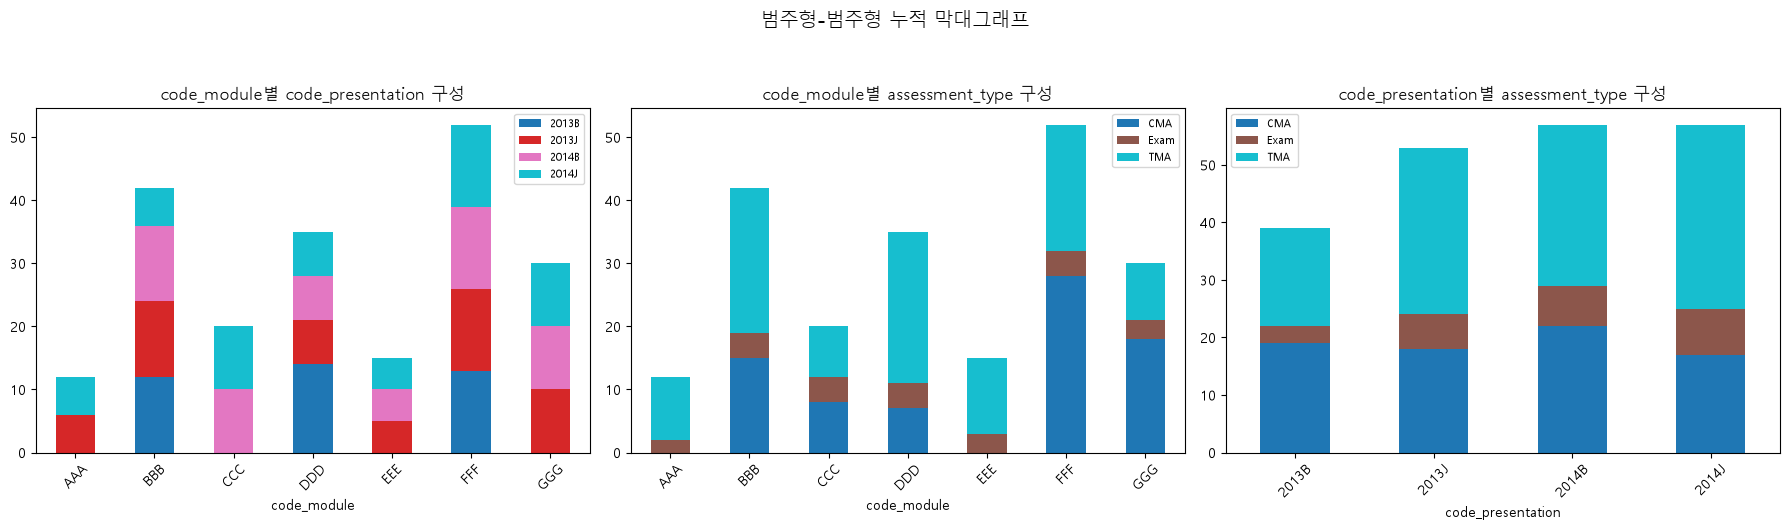

In [24]:
# 1-5 누적 막대 그래프

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))

for ax, (col1, col2) in zip(axes, pairs):
    cross = pd.crosstab(df[col1], df[col2])
    cross.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title(f'{col1}별 {col2} 구성')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

fig.suptitle('범주형-범주형 누적 막대그래프', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 3. 수치형 그래프

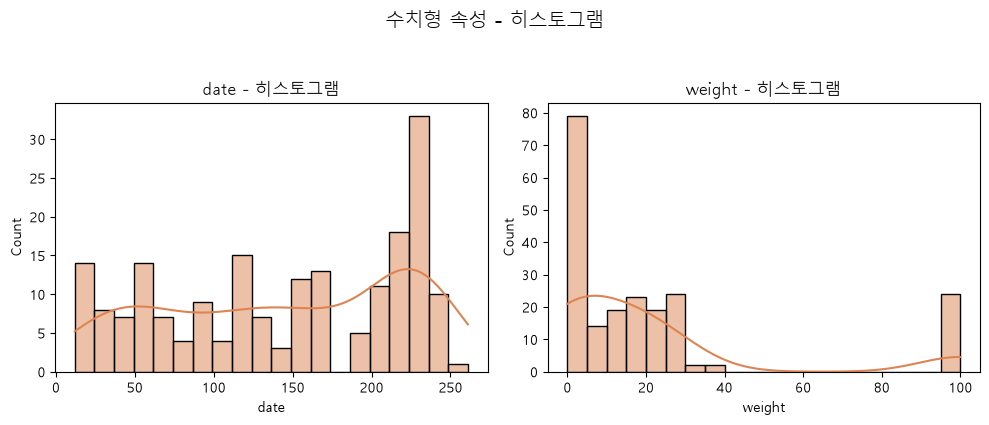

In [25]:
# 1-1 히스토그램(+KDE 곡선)

num_cols = ['date', 'weight']

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, bins=20, kde=True, color='#DD8452', ax=ax)
    ax.set_title(f'{col} - 히스토그램')

fig.suptitle('수치형 속성 - 히스토그램', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

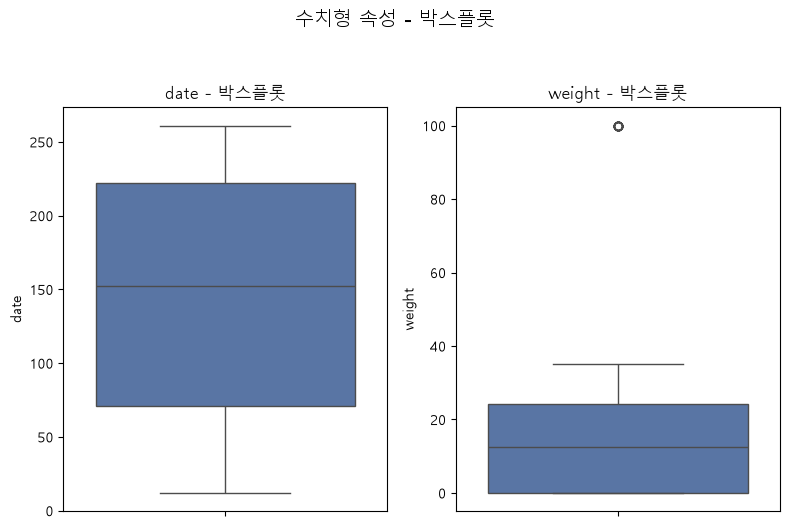

In [26]:
# 1-2 박스 플롯
# Q3 질문 도출

num_cols = ['date', 'weight']

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 박스플롯')

fig.suptitle('수치형 속성 - 박스플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

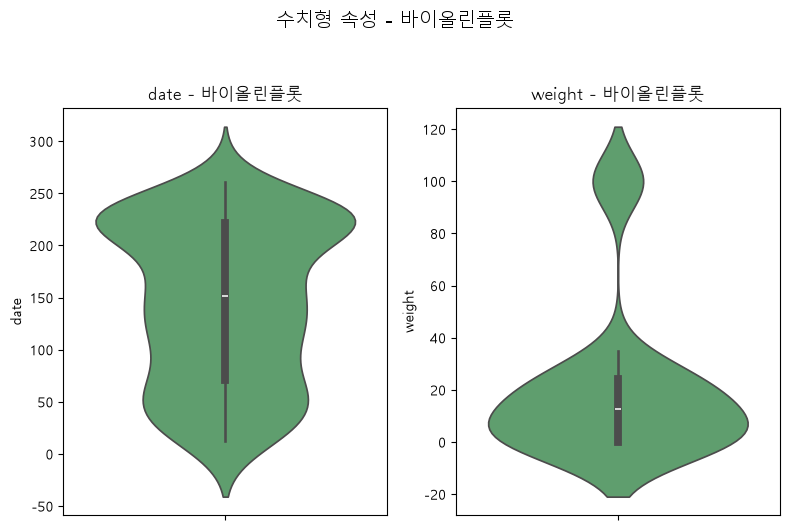

In [27]:
# 1-3 바이올린 플롯
# Q3 질문 도출

num_cols = ['date', 'weight']

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))

for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, y=col, color='#55A868', ax=ax)
    ax.set_title(f'{col} - 바이올린플롯')

fig.suptitle('수치형 속성 - 바이올린플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

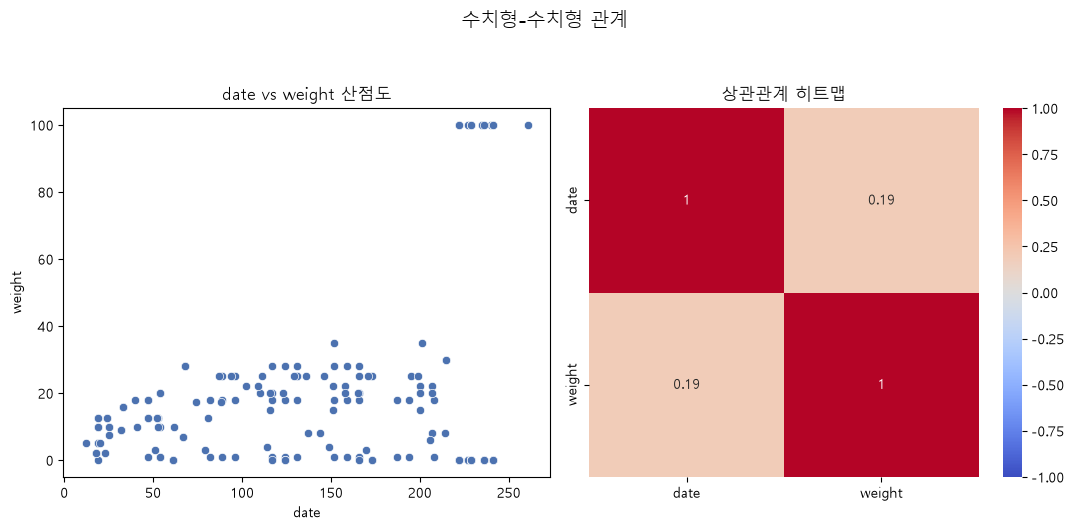

In [28]:
# 1-4 산점도, 히트맵

num_cols = ['date', 'weight']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.scatterplot(data=df, x='date', y='weight', color='#4C72B0', ax=axes[0])
axes[0].set_title('date vs weight 산점도')

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('상관관계 히트맵')

fig.suptitle('수치형-수치형 관계', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 4. 범주형과 수치형 종합

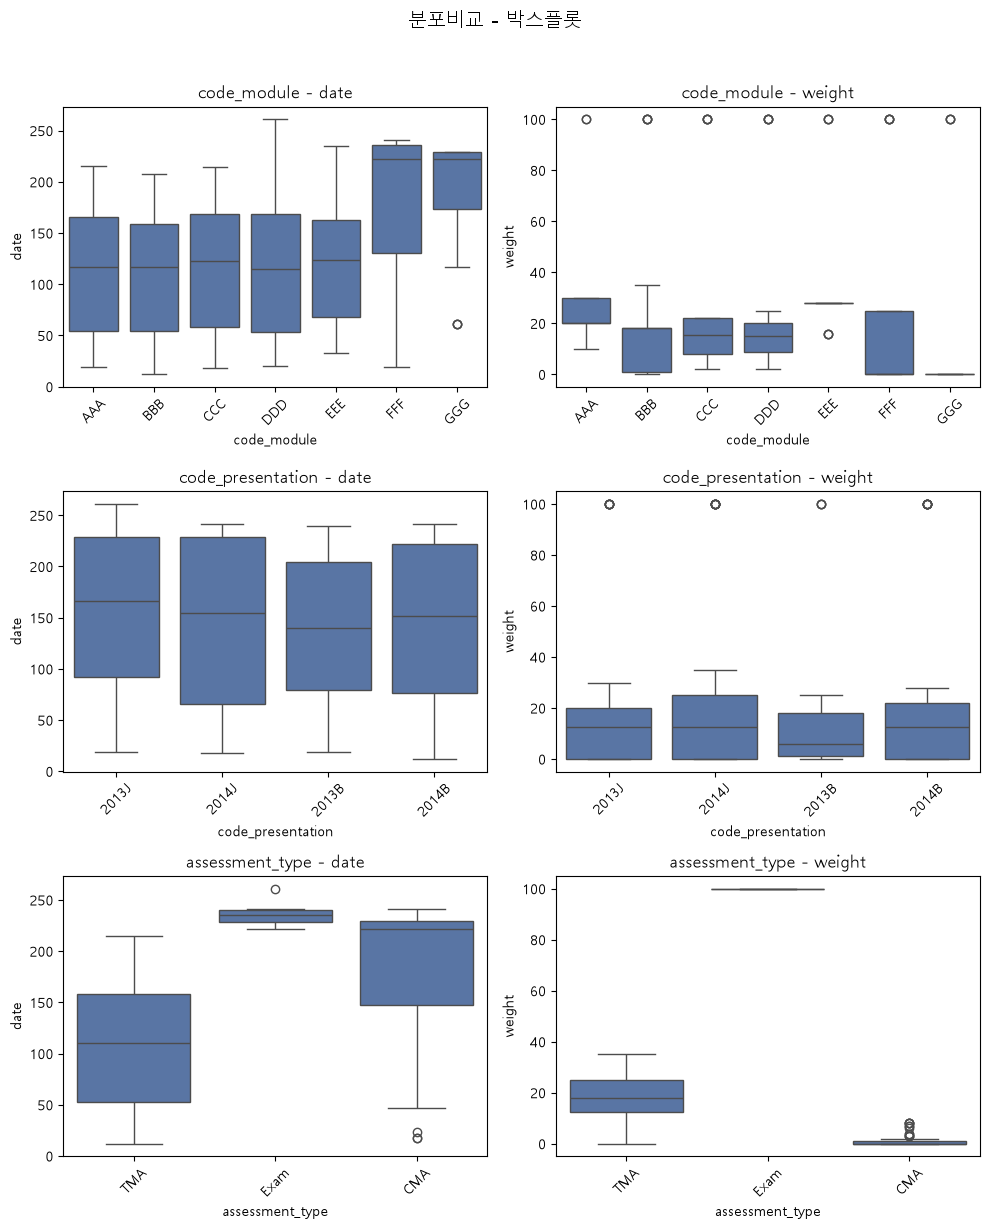

In [29]:
# 1-1 분포비교 - 박스플롯

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.boxplot(data=df, x=cat_col, y=num_col, color='#4C72B0', ax=ax)
        ax.set_title(f'{cat_col} - {num_col}')
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('분포비교 - 박스플롯', fontsize=14, y=1.02)
plt.tight_layout()

# ! 평가 비중이 0~5% 가 많은 이유? : 아마 TMA, CMA 의 영향이 큼

plt.show()

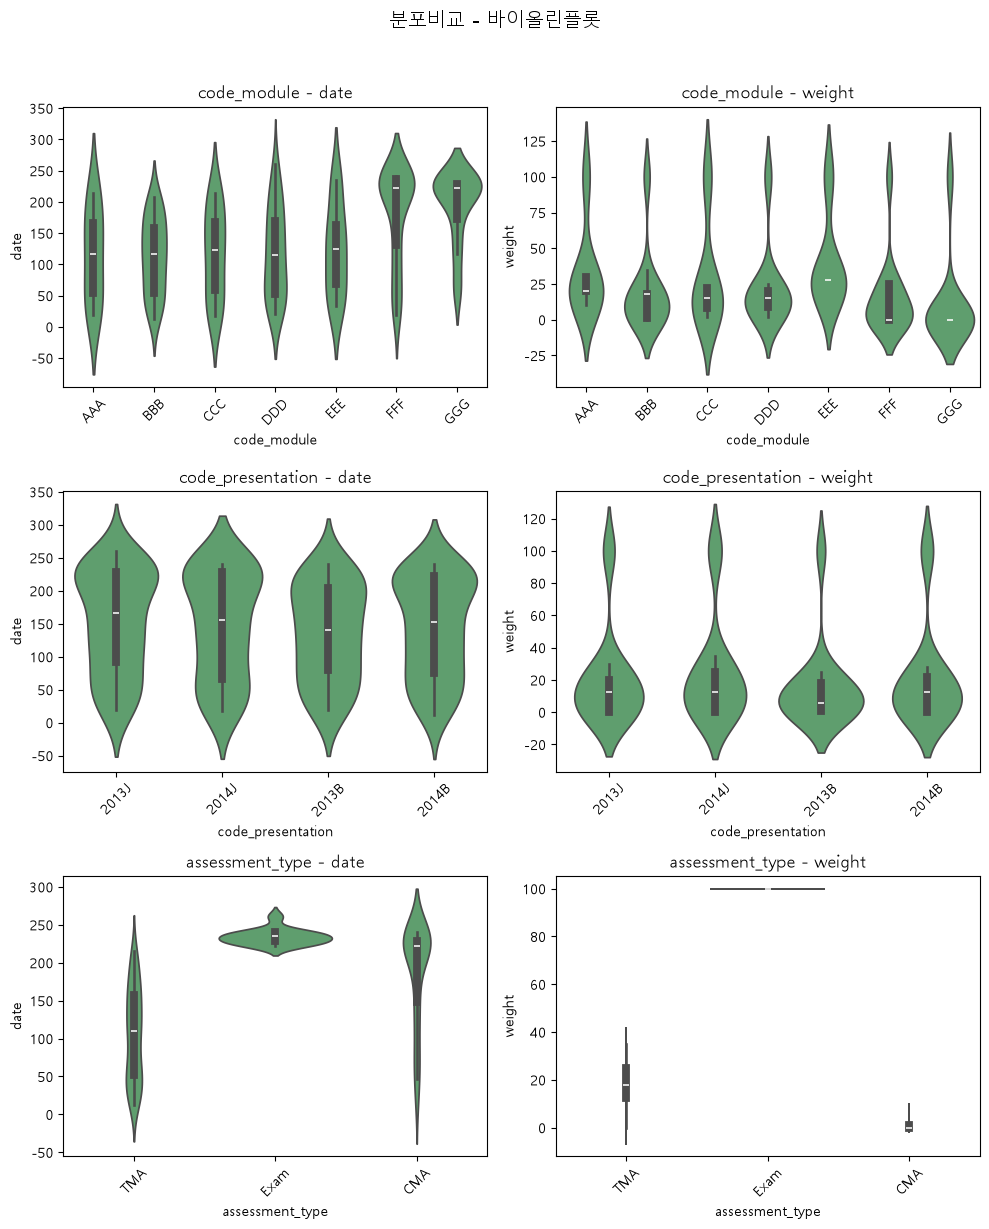

In [30]:
# 1-2 분포비교 - 바이올린 플롯

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.violinplot(data=df, x=cat_col, y=num_col, color='#55A868', ax=ax)
        ax.set_title(f'{cat_col} - {num_col}')
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('분포비교 - 바이올린플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

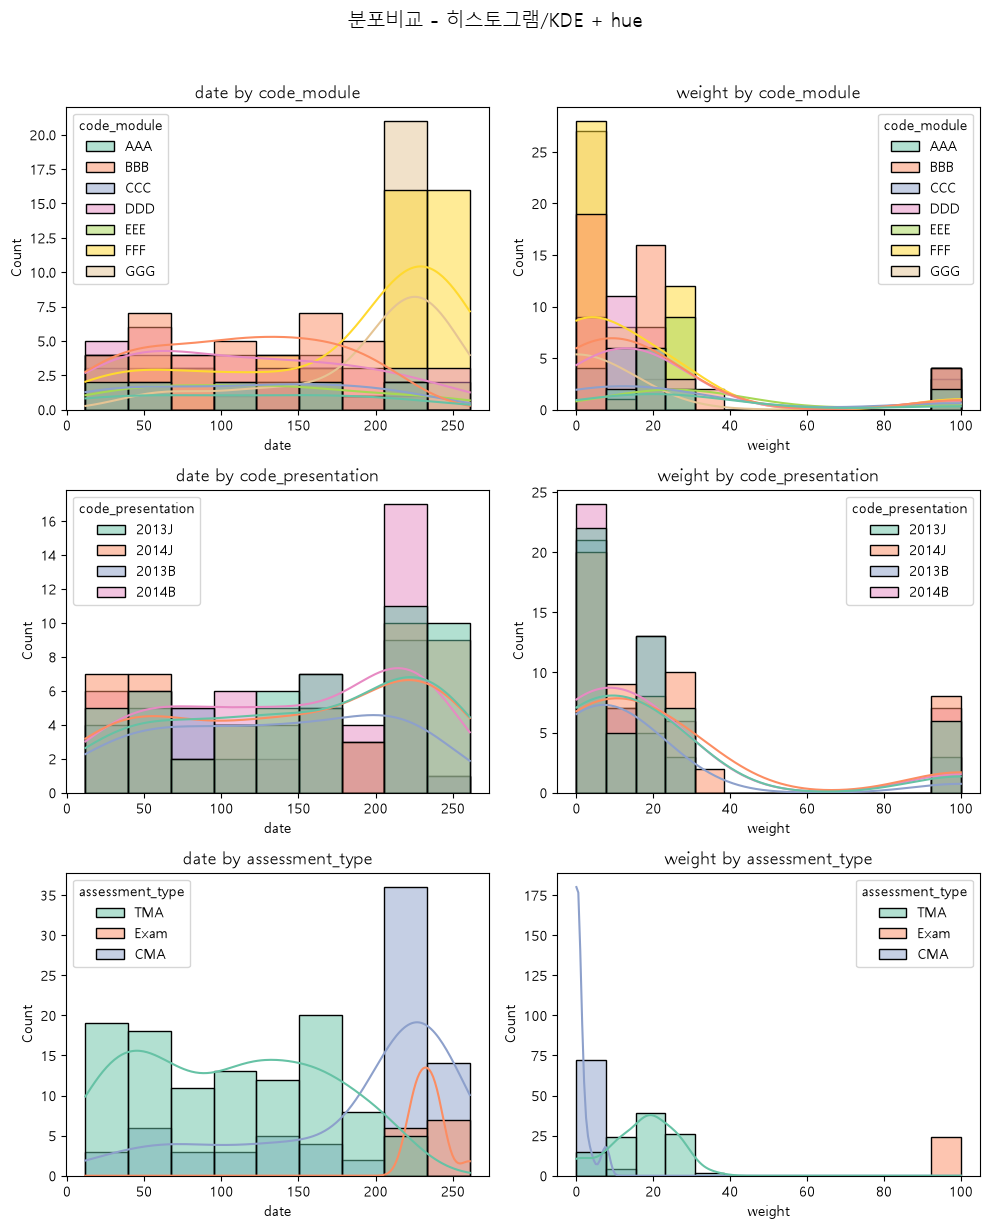

In [31]:
# 1-3 분포비교 - 히스토그램(+KDE)

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.histplot(data=df, x=num_col, hue=cat_col, kde=True, palette='Set2', ax=ax)
        ax.set_title(f'{num_col} by {cat_col}')

fig.suptitle('분포비교 - 히스토그램/KDE + hue', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

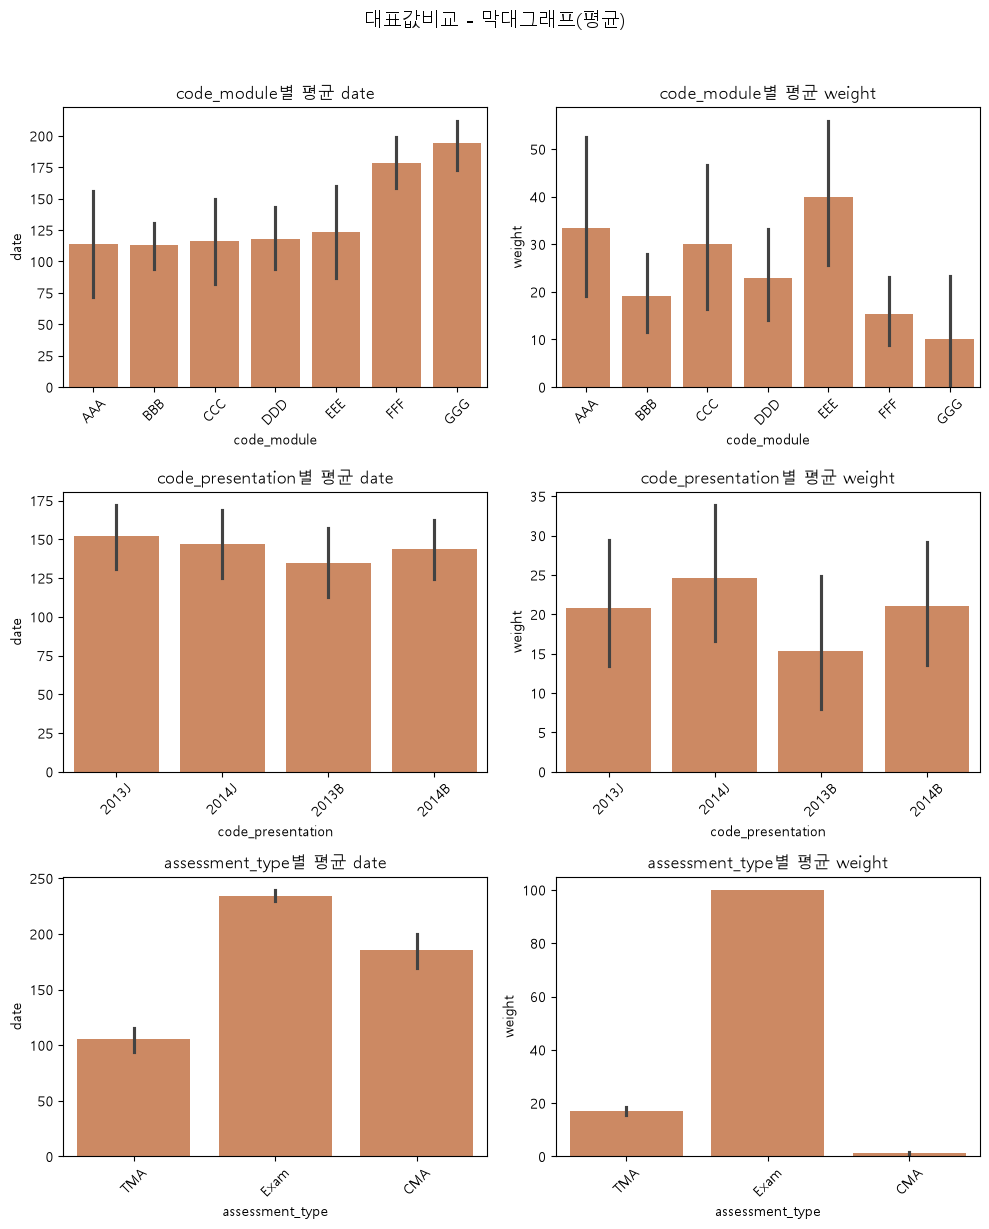

In [32]:
# 2-1 대표값 비교 - 막대그래프

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.barplot(data=df, x=cat_col, y=num_col, color='#DD8452', ax=ax)
        ax.set_title(f'{cat_col}별 평균 {num_col}')
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('대표값비교 - 막대그래프(평균)', fontsize=14, y=1.02)
plt.tight_layout()

'''
 막대 위에 나오는 검은 세로선은 **95% 신뢰구간(confidence interval)** 

 "이 평균값이 얼마나 믿을만한가/불확실한가"

 데이터 개수가 적거나 값이 들쭉날쭉한 카테고리일수록 이 선이 길게(넓게) 나오고, 
 데이터가 많고 일관되면 짧게 나옵니다. 내부적으로는 부트스트랩(재표본추출)으로 계산됨.
'''
plt.show()

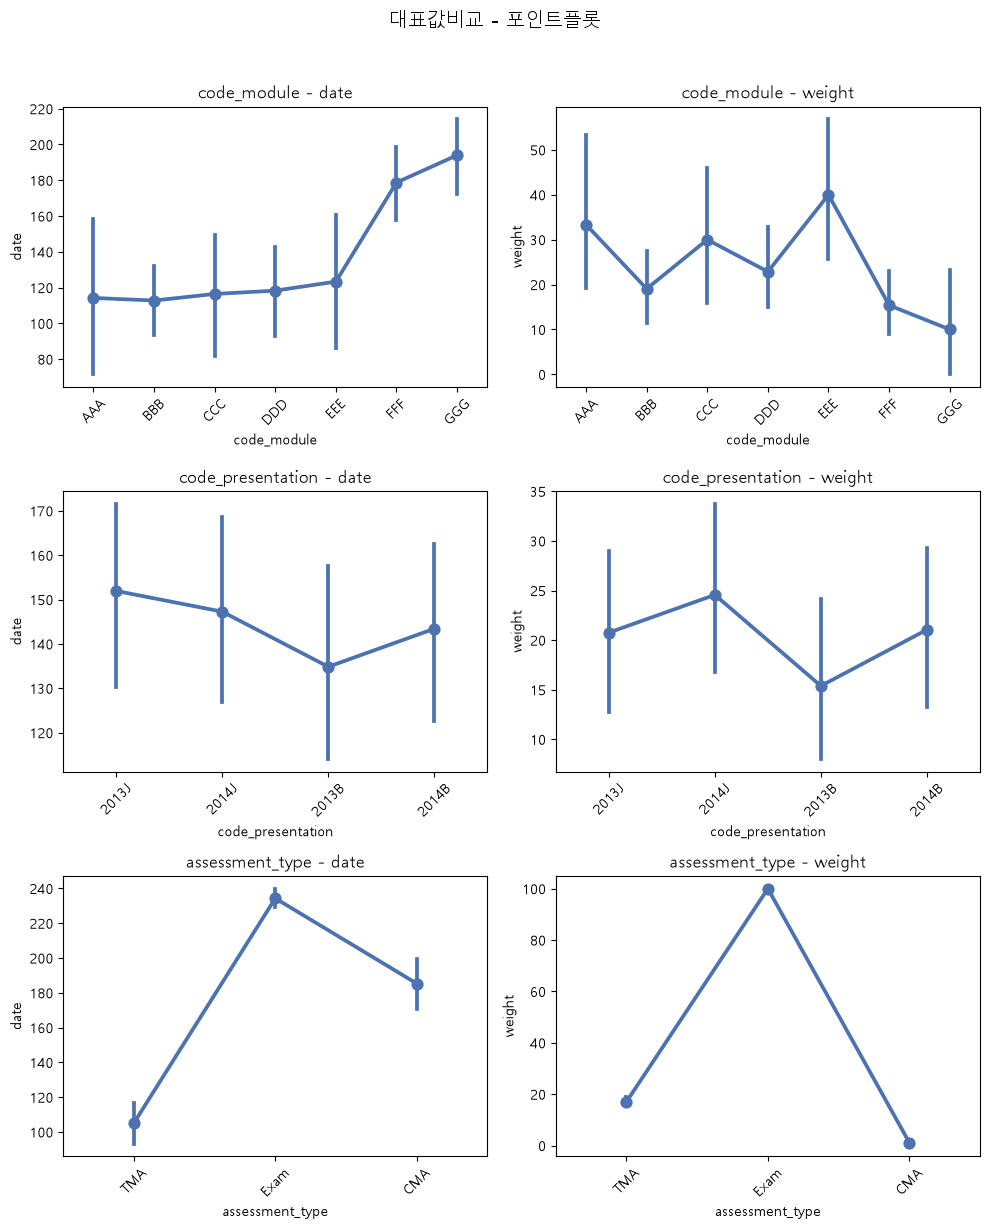

In [33]:
# 2-1 대표값 비교 - 포인트플롯

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.pointplot(data=df, x=cat_col, y=num_col, color='#4C72B0', ax=ax)
        ax.set_title(f'{cat_col} - {num_col}')
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('대표값비교 - 포인트플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

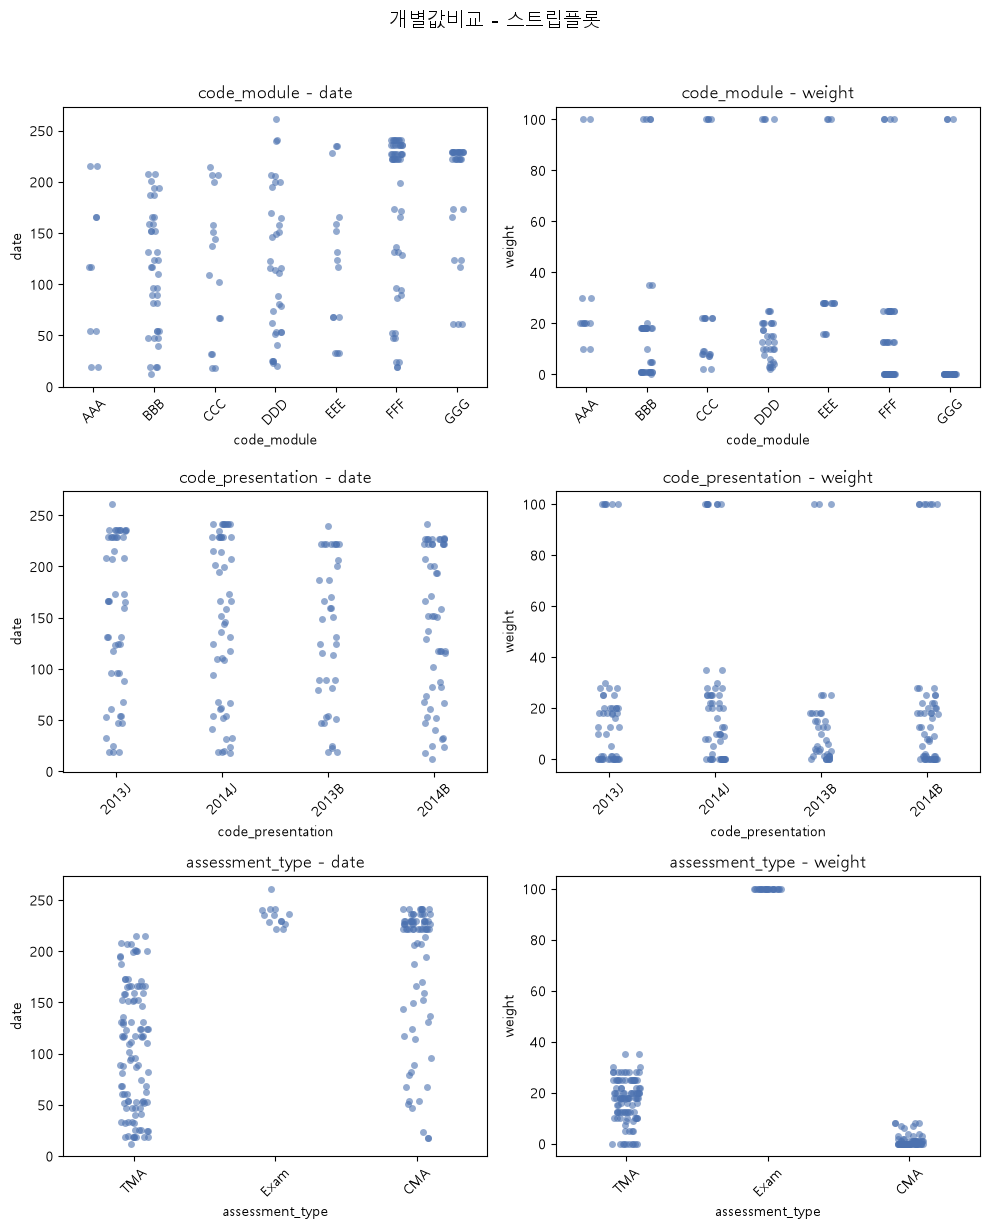

In [34]:
# 3-1 개별값 비교 - 스트립 플롯

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(5 * len(num_cols), 4 * len(cat_cols)))

for i, cat_col in enumerate(cat_cols):
    for j, num_col in enumerate(num_cols):
        ax = axes[i, j]
        sns.stripplot(data=df, x=cat_col, y=num_col, color='#4C72B0', alpha=0.6, ax=ax)
        ax.set_title(f'{cat_col} - {num_col}')
        ax.tick_params(axis='x', rotation=45)

fig.suptitle('개별값비교 - 스트립플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

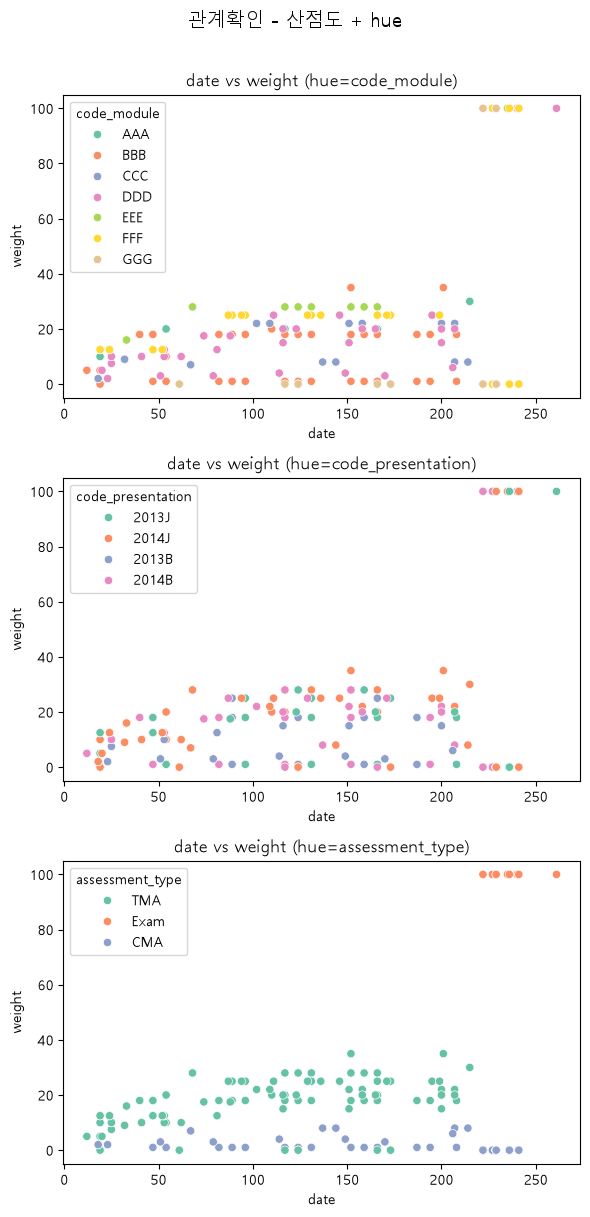

In [35]:
# 4-1 관계확인 - 산점도 + hue

cat_cols = ['code_module', 'code_presentation', 'assessment_type']
num_cols = ['date', 'weight']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(6, 4 * len(cat_cols)))

for ax, cat_col in zip(axes, cat_cols):
    sns.scatterplot(data=df, x='date', y='weight', hue=cat_col, palette='Set2', ax=ax)
    ax.set_title(f'date vs weight (hue={cat_col})')

fig.suptitle('관계확인 - 산점도 + hue', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 3. 현재 Assement.csv 에서 통계 검정(정규성 검정 등)이 필요 없는 이유

## 핵심 원칙
> **검정은 "질문"이 있을 때만 한다. 배웠으니까 일단 돌리는 것은 함정이다.**

정규성 검정·t검정·p-value 같은 통계 검정은 그 자체가 목적이 아니라,
특정 질문에 답하기 위한 **도구**다. 지금 단계(단일 CSV 이해)에는 아직 그 질문이 없다.

---

## 왜 지금(assessments 단독 분석)은 필요 없나

**1. assessments는 '정의표'라서 분포의 정규성이 의미가 없다**
- 각 평가가 무엇인지(유형·마감일·배점) 기록한 사전 성격의 표
- `weight`는 시험(100)과 과제(낮은 값)로 나뉘어 **이중봉**이 정상 → 정규가 아닌 게 당연
- 여기에 정규성 검정을 돌리면 "정규 아님"이라는 뻔한 답만 나옴

**2. 검정은 '비교/추론'을 할 때 쓰는 것**
정규성 확인이 실제로 필요한 경우는 두 가지뿐:
- 정규성을 **가정하는 검정**(t검정, ANOVA 등)을 하려 할 때
- **회귀 모델**을 만든 뒤 잔차가 정규인지 진단할 때

지금은 둘 다 아님 → 불필요

---

## 그럼 지금 필요한 '통계적인 것'은?
검정(p-value)이 아니라 **분포의 모양을 읽는 것**이 EDA의 통계다.

| 볼 것 | 무엇을 알 수 있나 |
|---|---|
| 평균 vs 중앙값 차이 | 크게 벌어지면 분포가 치우침(skew) → 평균 요약이 오해를 부름 |
| IQR·이상치(박스플롯 수염 밖) | 오류인지 진짜 현상인지 확인 대상 |
| 집단별 대표값 비교 | 유형별 weight 중앙값 차이 등 패턴 발견 |
| 히스토그램 모양(봉우리·치우침) | 집단이 섞여 있는지, 데이터 규칙이 있는지 |

---

## 검정이 진짜 필요해지는 순간 (나중 단계)
- **조인 후 교차 질문:** "TMA 점수와 CMA 점수 평균이 유의하게 다른가?"
  → 정규면 t검정, 아니면 Mann-Whitney
- **모델링:** 회귀 잔차 진단에서 정규성 확인

즉 **검정은 3단계(조인 후 교차 분석)나 모델링에서 등장하는 도구**이고,
단일 파일 이해 단계에서는 **분포 모양 읽기로 충분**하다.

---

## 한 줄 요약
> 지금은 "정규냐"를 검정으로 판정하지 말고, **히스토그램 모양·평균vs중앙값·치우침·이상치**를 눈으로 읽는다.
> 검정을 쓰고 싶어지면 먼저 물어라 — **"내가 지금 답하려는 질문이 두 집단 비교인가?"** 질문이 없으면 검정도 없다.

# 4. assessments.csv 단독으로 확인 가능한 질문 (검증은 조인 필요)

## Q1. 과목 -학기 별 평가 개수의 이탈률 영향

### 과정

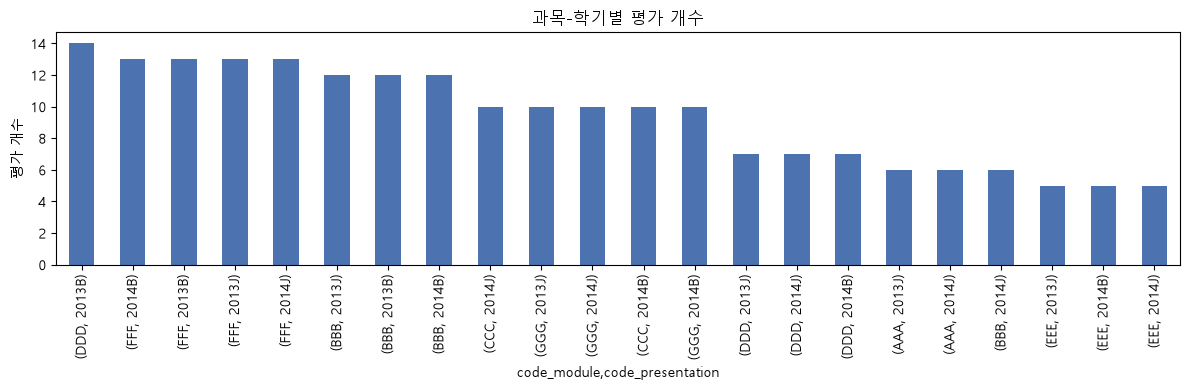

code_module  code_presentation
DDD          2013B                14
FFF          2014B                13
             2013B                13
             2013J                13
             2014J                13
BBB          2013J                12
             2013B                12
             2014B                12
CCC          2014J                10
GGG          2013J                10
             2014J                10
CCC          2014B                10
GGG          2014B                10
DDD          2013J                 7
             2014J                 7
             2014B                 7
AAA          2013J                 6
             2014J                 6
BBB          2014J                 6
EEE          2013J                 5
             2014B                 5
             2014J                 5
dtype: int64

In [36]:
# 평가가 촘촘한 과목일수록 부담이 커서 이탈과 관련될까?
# 근거 : 1-2 범주형 속성별 값 분포
# FFF(52) vs AAA(12) 개수 차이

q1 = df.groupby(['code_module', 'code_presentation']).size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
q1.plot(kind='bar', color='#4C72B0', ax=ax)
ax.set_title('과목-학기별 평가 개수')
ax.set_ylabel('평가 개수')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

q1

### 설명

모듈-학기 조합별 평가 개수는 최소 5개(EEE) ~ 최대 14개(DDD 2013B)로 약 3배 차이가 난다. 모듈별 평가 밀도가 다르다는 사실은 확인되지만, 이 밀도 차이가 실제 이탈로 이어지는지는 이 파일만으로는 알 수 없다 — `studentAssessment.csv`의 미제출률과 조인해야 검증 가능하다.

## Q2. 평가 마감일(`date`) 간격

### 과정

In [37]:
# 특정 구간에 평가가 몰려있는(간격이 짧은) 시기가 있을까?
# 근거 : 기술통계 / 1-3 사분위수 / 1-4 산점도, 히트맵


def gaps(g):
    d = g.sort_values('date')['date'].dropna()
    return d.diff().dropna()

rows = []
for (m, p), g in df.groupby(['code_module', 'code_presentation']):
    diffs = gaps(g)
    if len(diffs) == 0:
        continue
    rows.append({'code_module': m, 'code_presentation': p,
                 'min_gap': diffs.min(), 'max_gap': diffs.max(),
                 'mean_gap': diffs.mean(), 'n_assess': len(g)})

gap_df = pd.DataFrame(rows).sort_values('min_gap')
gap_df

,code_module,code_presentation,min_gap,max_gap,mean_gap,n_assess
3,BBB,2013J,0.0,42.0,18.900000,12
2,BBB,2013B,0.0,35.0,16.800000,12
4,BBB,2014B,0.0,42.0,18.200000,12
15,FFF,2013B,0.0,56.0,16.916667,13
19,GGG,2013J,0.0,63.0,18.666667,10
18,FFF,2014J,0.0,63.0,18.083333,13
17,FFF,2014B,0.0,56.0,16.916667,13
16,FFF,2013J,0.0,63.0,18.083333,13
21,GGG,2014J,0.0,63.0,18.666667,10
20,GGG,2014B,0.0,56.0,17.888889,10


In [38]:
# 같은 날짜에 마감이 겹치는 케이스의 존재

dup = df[df.duplicated(subset=['code_module', 'code_presentation', 'date'], keep=False)]
dup = dup[dup['date'].notna()].sort_values(['code_module', 'code_presentation', 'date'])
print('동일 마감일 겹치는 케이스 수:', len(dup))
dup.head(10)

동일 마감일 겹치는 케이스 수: 77


,code_module,code_presentation,id_assessment,assessment_type,date,weight
13,BBB,2013B,14992,CMA,89.0,1.0
19,BBB,2013B,14986,TMA,89.0,18.0
14,BBB,2013B,14993,CMA,124.0,1.0
20,BBB,2013B,14987,TMA,124.0,18.0
15,BBB,2013B,14994,CMA,159.0,1.0
21,BBB,2013B,14988,TMA,159.0,18.0
16,BBB,2013B,14995,CMA,187.0,1.0
22,BBB,2013B,14989,TMA,187.0,18.0
25,BBB,2013J,15004,CMA,96.0,1.0
31,BBB,2013J,14998,TMA,96.0,18.0


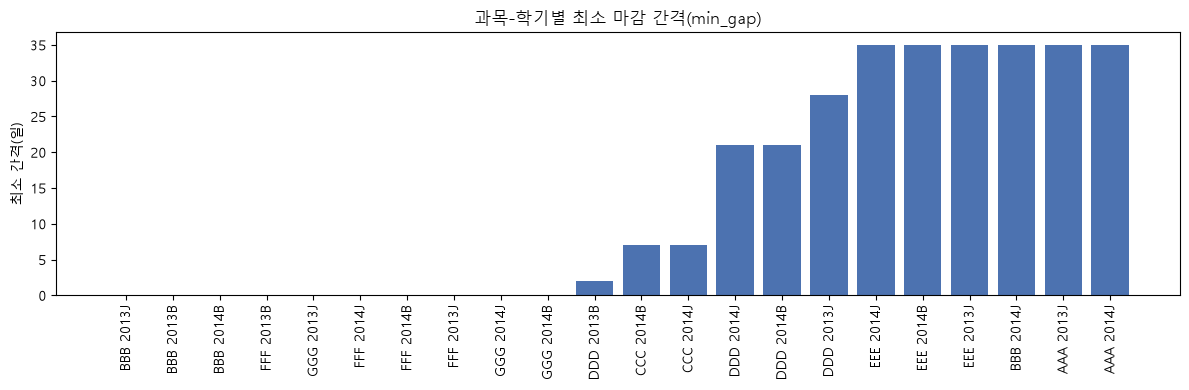

In [39]:
# Q2 보강: 과목-학기별 최소 마감 간격(min_gap) 시각화

labels = gap_df['code_module'] + ' ' + gap_df['code_presentation']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(labels, gap_df['min_gap'], color='#4C72B0')
ax.set_title('과목-학기별 최소 마감 간격(min_gap)')
ax.set_ylabel('최소 간격(일)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ! 막대가 0인 조합들이 앞쪽(왼쪽)에 몰려 있어, 특정 과목-학기에서 마감일 겹침이 흔하다는 걸 한눈에 보여줌

### 설명

모듈-학기 조합 중 다수가 최소 간격(min_gap) 0을 가진다. 즉 같은 날짜에 TMA와 CMA가 동시에 마감되는 경우가 전체 77건 존재한다. 특정 시점에 평가가 몰린다는 사실은 이 파일만으로 확인되지만, 이 시점이 실제 이탈 급증 구간과 겹치는지는 `studentVle.csv`, `studentAssessment.csv`와 조인해야 확인할 수 있다.

## Q3. 평가 비중(`weight`)에 따른 영향

### 과정

In [40]:
# 한두 개 평가(특히 Exam)에 비중이 몰린 과목과 고르게 분산된 과목이 있을까?
# 근거 : 왜도, 첨도 확인 / 1-2 박스 플롯 / 1-3 바이올린 플롯

rows = []
for (m, p), g in df.groupby(['code_module', 'code_presentation']):
    non_exam = g[g['assessment_type'] != 'Exam']
    if len(non_exam) == 0:
        continue
    rows.append({'code_module': m, 'code_presentation': p,
                 'max_weight': non_exam['weight'].max(),           # 시험을 제외한 평가의 비중 값
                 'std_weight': round(non_exam['weight'].std(), 1), # 시험을 제외한 평가의 표준편차(크면 한쪽에 비중이 몰림, 작으면 비중이 고름)
                 'n': len(non_exam)})                              # 시험이 아닌 평가의 수

w_df = pd.DataFrame(rows).sort_values('max_weight', ascending=False)
w_df

,code_module,code_presentation,max_weight,std_weight,n
5,BBB,2014J,35.0,15.4,5
0,AAA,2013J,30.0,7.1,5
1,AAA,2014J,30.0,7.1,5
14,EEE,2014J,28.0,6.0,4
13,EEE,2014B,28.0,6.0,4
12,EEE,2013J,28.0,6.0,4
17,FFF,2014B,25.0,11.1,12
16,FFF,2013J,25.0,11.1,12
15,FFF,2013B,25.0,11.1,12
11,DDD,2014J,25.0,9.3,6


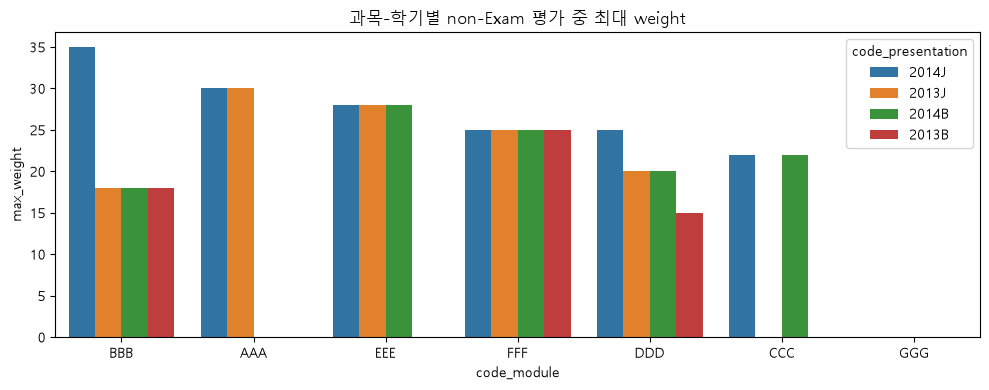

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=w_df, x='code_module', y='max_weight', hue='code_presentation', ax=ax)
ax.set_title('과목-학기별 non-Exam 평가 중 최대 weight')
plt.tight_layout()
plt.show()

### 설명

과목별로 non-Exam 평가의 최대 비중과 표준편차 차이가 뚜렷하다. BBB(2014J)는 최대 35%짜리 과제가 있는 반면, GGG는 모든 학기에서 non-Exam weight가 전부 0 — 즉 TMA/CMA가 성적에 전혀 반영되지 않고 사실상 Exam(100%)으로만 평가되는 구조다. 이 구조 차이가 학생의 과제 참여 동기(→ 이탈)에 영향을 줄 수 있다는 가설을 세울 수 있다.

## Q4. Exam 직전 마지막 TMA/CMA와 Exam 사이 간격(공백 기간)이 과목마다 다를까?

### 과정

In [42]:
# 근거 : 1-4 결측치 위치 조회

rows = []
for (m, p), g in df.groupby(['code_module', 'code_presentation']):
    exam = g[g['assessment_type'] == 'Exam']
    others = g[g['assessment_type'] != 'Exam'].dropna(subset=['date'])
    if len(exam) == 0 or len(others) == 0:
        continue
    exam_date = exam['date'].max()
    last_other_date = others['date'].max()
    gap = exam_date - last_other_date if pd.notna(exam_date) else None
    rows.append({'code_module': m, 'code_presentation': p,
                 'exam_date': exam_date, 'last_other_date': last_other_date, 'gap': gap})

gap4_df = pd.DataFrame(rows)
gap4_df

,code_module,code_presentation,exam_date,last_other_date,gap
0,AAA,2013J,NaN,215.0,NaN
1,AAA,2014J,NaN,215.0,NaN
2,BBB,2013B,NaN,187.0,NaN
3,BBB,2013J,NaN,208.0,NaN
4,BBB,2014B,NaN,194.0,NaN
5,BBB,2014J,NaN,201.0,NaN
6,CCC,2014B,NaN,207.0,NaN
7,CCC,2014J,NaN,214.0,NaN
8,DDD,2013B,240.0,206.0,34.0
9,DDD,2013J,261.0,207.0,54.0


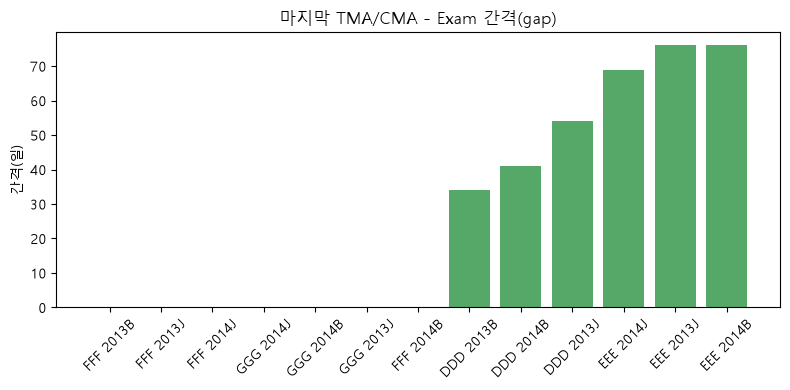

In [43]:
# Q4 보강: 마지막 TMA/CMA - Exam 간격(gap) 시각화 (Exam 날짜가 있는 조합만)

gap4_plot = gap4_df.dropna(subset=['gap']).sort_values('gap')
labels4 = gap4_plot['code_module'] + ' ' + gap4_plot['code_presentation']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels4, gap4_plot['gap'], color='#55A868')
ax.set_title('마지막 TMA/CMA - Exam 간격(gap)')
ax.set_ylabel('간격(일)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ! FFF, GGG는 gap이 0으로 붙어 있고, EEE로 갈수록 공백 기간이 길어지는 게 시각적으로 뚜렷해짐

### 설명

AAA, BBB, CCC는 Exam `date` 자체가 결측이라 gap을 계산할 수 없다 (앞서 확인한 'Exam 날짜 결측 11건'과 같은 맥락). FFF, GGG는 gap이 0으로, Exam 날짜가 마지막 TMA/CMA와 동일하게 기록돼 있다. 반면 EEE는 gap이 69~76일로 커서, 마지막 과제 이후 시험까지 상당한 공백기가 있다. 이 공백기가 길수록 긴장이 풀려 이탈 위험이 커지는지, 아니면 짧을수록 부담이 몰려 이탈 위험이 커지는지는 아직 이 파일만으로 판단할 수 없다.

## Q5. 학기(`code_presentation`) 별로 총 평가 개수나 `weight` 분포 패턴이 다를까?

### 과정

In [44]:
# 근거 : 1-2 범주형 속성별 값 분포 / 1-5 히트맵(범주형 끼리 관계) : 2013B만 개수가 적음

q5 = df.groupby('code_presentation').agg(
    n_assessments=('id_assessment', 'count'),
    n_modules=('code_module', 'nunique'),
    weight_mean=('weight', 'mean'),
    weight_median=('weight', 'median'),
    weight_std=('weight', 'std'),
).round(2)
q5

,n_assessments,n_modules,weight_mean,weight_median,weight_std
code_presentation,,,,,
2013B,39,3,15.38,6.0,26.00
2013J,53,6,20.75,12.5,30.25
2014B,57,6,21.05,12.5,31.24
2014J,57,7,24.56,12.5,32.56


In [45]:
pd.crosstab(df['code_presentation'], df['assessment_type'])

assessment_type,CMA,Exam,TMA
code_presentation,,,
2013B,19,3,17
2013J,18,6,29
2014B,22,7,28
2014J,17,8,32


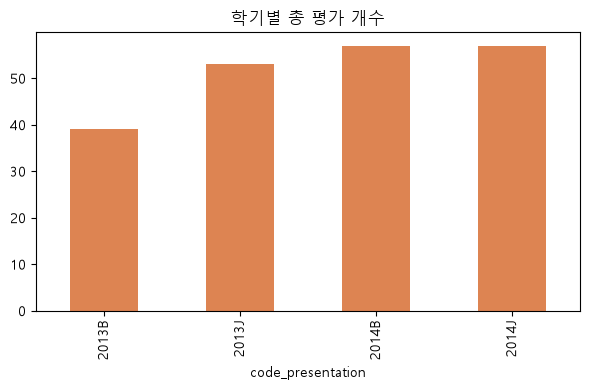

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
q5['n_assessments'].plot(kind='bar', color='#DD8452', ax=ax)
ax.set_title('학기별 총 평가 개수')
plt.tight_layout()
plt.show()

### 설명

2013B는 개설된 모듈이 3개뿐이라 총 평가 개수가 39개로 가장 적다 (다른 학기는 6~7개 모듈, 53~57개). 반면 weight 평균/중앙값/표준편차는 학기 간 큰 차이가 없다. 

즉 '학기 자체' 차이보다는 '그 학기에 어떤 과목이 개설됐는지'가 더 큰 변수로 보인다.

# 5. assessments.csv ↔ 이탈률(dropout) 연결 질문(조인 필요)

## 질문

- `date`(마감일)을 통해 이탈이 특정 평가 마감일 전후에 몰려있는가?
- `assessment_type`별로 이탈률에 차이가 있을까? = TMA를 안 낸 사람과 CMA를 안 낸 사람 중 어느 쪽이 이탈로 더 많이 이어지는가?
- `weight`가 큰 평가(예: Exam)를 놓친 것과 `weight`가 작은 평가를 놓친 것, 이탈에 미치는 영향이 어떤가?
- 지금 이 파일에서 "이탈과 무관해 보이는" 속성은? (`id_assessment` 자체, `code_presentation`(개강학기)는 직접 원인이라기보단 통제 변수에 가까울 것 같음)